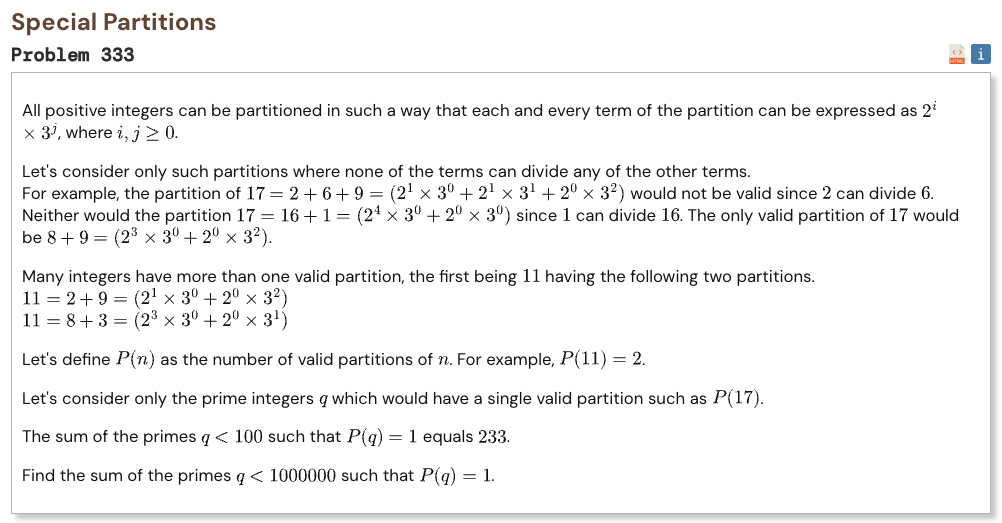

## Initial approach

* generate all usable terms below the limit
* valid partitions are not normal subsets
* when the power of 2 goes up, the power of 3 must go down
* keep bitsets for sums that appear once and sums that appear more than once
* cap counts at two because we only care whether a prime has exactly one partition
* after processing all terms, combine all final states
* sum only the primes whose partition count is exactly one

In [1]:
import math

def prime_sieve(limit):
    is_prime = bytearray(b"\x01") * limit
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit - 1) + 1):
        if is_prime[p]:
            is_prime[p * p:limit:p] = b"\x00" * (((limit - 1 - p * p) // p) + 1)

    return is_prime

def add_counts(once_a, many_a, once_b, many_b, mask):
    many = many_a | many_b | (once_a & once_b)
    once = (once_a ^ once_b) & ~many
    return once & mask, many & mask

def solve(limit):
    powers_2 = []
    value = 1

    while value < limit:
        powers_2.append(value)
        value *= 2

    powers_3 = []
    value = 1

    while value < limit:
        powers_3.append(value)
        value *= 3

    max_j = len(powers_3) - 1
    mask = (1 << limit) - 1

    states = [(0, 0) for _ in range(max_j + 2)]
    states[max_j + 1] = (1, 0)

    for power_2 in powers_2:
        new_states = states[:]

        for upper_j, (once, many) in enumerate(states):
            if once == 0 and many == 0:
                continue

            for j in range(upper_j):
                term = power_2 * powers_3[j]

                if term >= limit:
                    continue

                shifted_once = (once << term) & mask
                shifted_many = (many << term) & mask

                old_once, old_many = new_states[j]
                new_states[j] = add_counts(old_once, old_many, shifted_once, shifted_many, mask)

        states = new_states

    total_once = 0
    total_many = 0

    for once, many in states:
        total_once, total_many = add_counts(total_once, total_many, once, many, mask)

    is_prime = prime_sieve(limit)
    result = 0

    for n in range(2, limit):
        if is_prime[n] and ((total_once >> n) & 1):
            result += n

    return result

assert solve(100) == 233

In [2]:
%%time
result = solve(1_000_000)
print("Result:", result)

Result: 3053105
CPU times: user 1.13 s, sys: 12.8 ms, total: 1.15 s
Wall time: 1.16 s
